In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from importlib import reload
from numpy.random import standard_t, normal

import robust_filter

reload(robust_filter)

from data_processing import daily_stock_std
from robust_filter import Filter, score_func, kalman_func

Data preparation

In [2]:
ROOT = Path.cwd()
PROJECT_ROOT = ROOT
DATA_DIR = PROJECT_ROOT / "data"
DATA_PATH = DATA_DIR / "bin201901.csv"
DATA_PATH

PosixPath('/Users/elsaemiliabodle/VSCodeProjects/robust-filtering/data/bin201901.csv')

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
df_subset = df[df["stock"] == "AAPL"]
df_subset.head()

,date,time,stock,trade,orderFlow,hidden,auction,mid,midEnd,spread,effSpread,lobImb,effLobImb,trdLiq,ofLiq,depth,nbEvents,nbHidden,nbTrades
6627,2019-01-02,09:30:00,AAPL,-11855,-14141,12397,419249,154.915,154.755,0.055,0.156354,0.866667,0.261039,18657,68751,277.6250,8,1,2
6628,2019-01-02,09:30:10,AAPL,527,3346,4579,0,154.640,154.645,0.070,0.055760,0.000000,-0.659986,11359,42698,313.8571,7,1,2
6629,2019-01-02,09:30:20,AAPL,-2979,7161,1765,0,154.595,154.605,0.045,0.041798,0.333333,-0.010202,6573,78475,337.6250,8,1,2
6630,2019-01-02,09:30:30,AAPL,5120,12162,1663,0,154.600,154.620,0.010,0.015000,0.666667,0.703877,7322,106242,897.1111,9,1,2
6631,2019-01-02,09:30:40,AAPL,8889,29297,1038,0,154.885,154.875,0.035,0.029257,0.760000,0.640284,12651,126539,831.2500,8,1,2


In [5]:
std_df = daily_stock_std(df_subset, date_col="date", stock_col="stock", value_col="mid")
std_df.head(10)

,date,stock,mid_std
0,2019-01-02,AAPL,1.120240
1,2019-01-03,AAPL,0.911967
2,2019-01-04,AAPL,0.984060
3,2019-01-07,AAPL,0.583499
4,2019-01-08,AAPL,0.818250
5,2019-01-09,AAPL,0.486091
6,2019-01-10,AAPL,0.608748
7,2019-01-11,AAPL,0.427133
8,2019-01-14,AAPL,0.246215
9,2019-01-15,AAPL,0.613424


Generate data

In [ ]:
N = 1000

# True system parameters (unknown to filter)
mu_0_true = 0
theta_true = 0.9
nu_true = 20
sigma_true = 0.2
process_noise_std = 0.8  # Standard deviation of process noise

In [19]:
# Generate true latent state process: AR(1) with Gaussian process noise
process_noise = normal(0, process_noise_std, N - 1)
mu_true = [mu_0_true]
for e in process_noise:
    mu_t = mu_true[-1]
    mu_next = theta_true * mu_t + e
    mu_true.append(mu_next)
print(f"True state mean: {np.mean(mu_true):.3f}, std: {np.std(mu_true):.3f}")

True state mean: 0.060, std: 1.772


In [20]:
# Generate measurement noise: Student-t distribution (robust to outliers)
measurement_noise = standard_t(nu_true, N) * sigma_true
print(
    f"Noise mean: {np.mean(measurement_noise):.3f}, std: {np.std(measurement_noise):.3f}"
)

Noise mean: -0.016, std: 0.208


In [21]:
# Generate observations: true state + measurement noise
y = [m + n for m, n in zip(mu_true, measurement_noise)]
print(f"Observation mean: {np.mean(y):.3f}, std: {np.std(y):.3f}")

Observation mean: 0.045, std: 1.788


Parameter estimation

In [ ]:
from parameter_estimation import generate_param_grid, grid_search

In [23]:
param_grid = {
    "nu": np.arange(1, 10, 1),
    "sigma": np.arange(0.1, 1.0, 0.1),
    "theta": np.arange(0.1, 1.0, 0.1),
    "kappa": np.arange(0.1, 1.0, 0.1),
}
param_dicts = generate_param_grid(param_grid)

In [ ]:
best_params_score = grid_search(y, y[0], param_dicts, score_func)

In [ ]:
score_filter = Filter(mu_0=y[0], param_dict=best_params_score, func=score_func)

In [ ]:
best_params_kalman = grid_search(y, y[0], param_dicts, kalman_func)

In [ ]:
kalman_filter = Filter(mu_0=y[0], param_dict=best_params_kalman)

In [ ]:
score_filter.update(y)

[np.float64(-0.10217662914615547),
 np.float64(0.01561212093672247),
 np.float64(0.1696518094392806),
 np.float64(-0.08603845198463758),
 np.float64(-0.2924824684493851),
 np.float64(-0.3313339151326515),
 np.float64(-0.5013238955907833),
 np.float64(-0.6062590036111922),
 np.float64(-0.5568813808693092),
 np.float64(-0.7950547369305201),
 np.float64(-0.6689785386060395),
 np.float64(-0.31349420764076974),
 np.float64(-0.014012793600231888),
 np.float64(0.28672931802744256),
 np.float64(0.4763930941788632),
 np.float64(0.6901197033570508),
 np.float64(0.3159047829238333),
 np.float64(0.00932361092718792),
 np.float64(0.301735929305438),
 np.float64(0.5543463780959672),
 np.float64(0.7646645532807681),
 np.float64(0.9747874046447441),
 np.float64(0.878310759629023),
 np.float64(0.9130303667709453),
 np.float64(1.0799949852633621),
 np.float64(0.6687280927727226),
 np.float64(0.30309811119310776),
 np.float64(0.5353303681727866),
 np.float64(0.31186000419471505),
 np.float64(0.1018929499

In [ ]:
kalman_filter.update(y)

[np.float64(-0.1051915948966773),
 np.float64(0.017947665676846927),
 np.float64(0.18218602963191644),
 np.float64(-1.1195432622563422),
 np.float64(-0.7420843970863181),
 np.float64(-0.5120383625545062),
 np.float64(-1.9842797806492585),
 np.float64(-1.2109098312233288),
 np.float64(-0.7987455096086119),
 np.float64(-1.056787808465854),
 np.float64(-0.7733992616407149),
 np.float64(0.22297385877655562),
 np.float64(0.9693577771218365),
 np.float64(1.1388219895813494),
 np.float64(0.8555974062208318),
 np.float64(0.9241344571105293),
 np.float64(0.051173247413285106),
 np.float64(-0.20357377449150313),
 np.float64(0.3792432206776887),
 np.float64(1.2198505167574796),
 np.float64(1.1202411761521263),
 np.float64(1.2543747209469702),
 np.float64(0.9901456888333934),
 np.float64(0.9631099902571982),
 np.float64(1.177797682815537),
 np.float64(0.30768470177802154),
 np.float64(-0.307572964585338),
 np.float64(0.37521243687470934),
 np.float64(0.2322130256071975),
 np.float64(0.051466411575

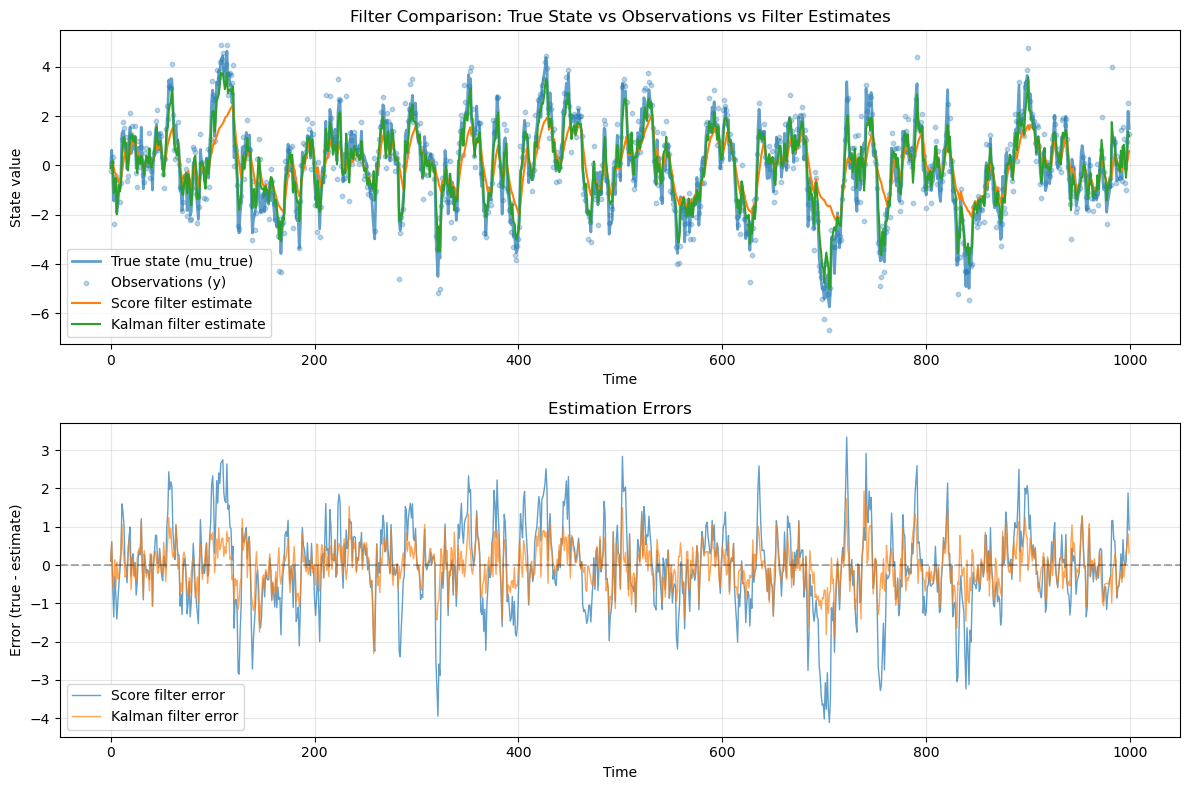

Score filter MSE: 1.1970
Kalman filter MSE: 0.3199


In [131]:
# Plot results
t = np.arange(N)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Full time series
axes[0].plot(t, mu_true, label="True state (mu_true)", linewidth=2, alpha=0.7)
axes[0].scatter(t, y, label="Observations (y)", alpha=0.3, s=10)
axes[0].plot(t, score_filter.mu, label="Score filter estimate", linewidth=1.5)
axes[0].plot(t, kalman_filter.mu, label="Kalman filter estimate", linewidth=1.5)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("State value")
axes[0].set_title("Filter Comparison: True State vs Observations vs Filter Estimates")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Estimation errors
error_score = [mt - ms for mt, ms in zip(mu_true, score_filter.mu)]
error_kalman = [mt - mk for mt, mk in zip(mu_true, kalman_filter.mu)]
axes[1].plot(t, error_score, label="Score filter error", linewidth=1, alpha=0.7)
axes[1].plot(t, error_kalman, label="Kalman filter error", linewidth=1, alpha=0.7)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Error (true - estimate)")
axes[1].set_title("Estimation Errors")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color="k", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Score filter MSE: {np.mean(np.array(error_score) ** 2):.4f}")
print(f"Kalman filter MSE: {np.mean(np.array(error_kalman) ** 2):.4f}")